# Phase 4 — Evaluation, Calibration, Explainability, and Domain Adaptation

This notebook evaluates the final Phase 3 models using the revised split strategy:

- **Cleveland train + validation** were used for final model fitting in Phase 3.
- **Cleveland held-out test** is evaluated here for the first time.
- **Hungarian** and **Swiss** are evaluated here as untouched external test sets.


The notebook is for inspection/reporting only. The Python runner `src/04_evaluation.py` should be used to generate saved tables and figures.

## Imports

In [1]:
from pathlib import Path
import importlib.util
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    confusion_matrix,
)

try:
    from sklearn.frozen import FrozenEstimator
except Exception:
    FrozenEstimator = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

## Project paths

This notebook assumes it is inside the `notebooks/` directory. If it is run from the project root, the path logic still works.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_MODEL_DIR = PROJECT_ROOT / "outputs" / "models"
OUTPUT_TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

RAW_FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal",
]

print("Project root:", PROJECT_ROOT)
print("Processed data dir:", PROCESSED_DATA_DIR)
print("Model dir:", OUTPUT_MODEL_DIR)

Project root: /Users/aexomir/Desktop/AIMed
Processed data dir: /Users/aexomir/Desktop/AIMed/data/processed
Model dir: /Users/aexomir/Desktop/AIMed/outputs/models


## Load Phase 3 custom classes and saved models

The saved models contain the custom `ClinicalFeatureEngineer` class from `src/03_modeling.py`.  
Therefore, the notebook first imports `03_modeling.py` under the stable module name `phase3_modeling`, then loads the `.joblib` models.

In [3]:
def import_module_from_src(module_filename: str, module_name: str):
    path = SRC_DIR / module_filename
    if not path.exists():
        raise FileNotFoundError(f"Cannot find required module: {path}")

    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not import module from {path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


# Register Phase 3 classes before loading joblib models.
phase3 = import_module_from_src("03_modeling.py", "phase3_modeling")

required_model_files = {
    "Logistic Regression": OUTPUT_MODEL_DIR / "phase3_logistic_regression.joblib",
    "XGBoost + Optuna": OUTPUT_MODEL_DIR / "phase3_xgboost_optuna.joblib",
    "Small MLP": OUTPUT_MODEL_DIR / "phase3_small_mlp.joblib",
}

missing = [str(path) for path in required_model_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing Phase 3 model files. Run `python src/03_modeling.py` first. Missing:\n"
        + "\n".join(missing)
    )

models = {
    model_name: joblib.load(path)
    for model_name, path in required_model_files.items()
}

models

{'Logistic Regression': Pipeline(steps=[('preprocess',
                  Pipeline(steps=[('features', ClinicalFeatureEngineer()),
                                  ('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model',
                  LogisticRegression(C=0.5, max_iter=5000, penalty='l2',
                                     random_state=42))]),
 'XGBoost + Optuna': Pipeline(steps=[('preprocess',
                  Pipeline(steps=[('features', ClinicalFeatureEngineer()),
                                  ('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=0.6656827730154452, device=None,
                      

## Load evaluation splits

Phase 4 evaluates three untouched test domains:

1. Cleveland held-out test
2. Hungarian external test
3. Swiss external test

In [4]:
def load_split(filename: str) -> pd.DataFrame:
    path = PROCESSED_DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing processed split: {path}")

    df = pd.read_csv(path)
    for col in RAW_FEATURES + ["target"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["target"] = df["target"].astype(int)
    return df


def get_xy(df: pd.DataFrame):
    return df[RAW_FEATURES].copy(), df["target"].copy()


train_df = load_split("cleveland_train.csv")
validation_df = load_split("cleveland_validation.csv")
train_validation_df = pd.concat([train_df, validation_df], ignore_index=True)

eval_splits = {
    "cleveland_test": load_split("cleveland_test.csv"),
    "hungarian": load_split("hungarian.csv"),
    "swiss": load_split("swiss.csv"),
}

for name, df in eval_splits.items():
    print(f"{name:15s} shape={df.shape}, positive_rate={df['target'].mean():.2%}")

cleveland_test  shape=(46, 17), positive_rate=45.65%
hungarian       shape=(294, 17), positive_rate=36.05%
swiss           shape=(123, 17), positive_rate=93.50%


## Performance evaluation

Metrics:

- AUC-ROC
- AUC-PR
- F1
- sensitivity
- specificity

Threshold-dependent metrics use the default threshold of **0.5**. This avoids tuning thresholds on external test sets.

In [5]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan


def evaluate_predictions(y_true, prob):
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    pred = (prob >= 0.5).astype(int)

    return {
        "roc_auc": float(roc_auc_score(y_true, prob)) if len(np.unique(y_true)) > 1 else np.nan,
        "average_precision": float(average_precision_score(y_true, prob)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "sensitivity": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": specificity_score(y_true, pred),
    }


def evaluate_models(models, eval_splits):
    rows = []
    predictions = {}

    for split_name, df in eval_splits.items():
        X, y = get_xy(df)

        for model_name, model in models.items():
            prob = model.predict_proba(X)[:, 1]
            predictions[(split_name, model_name)] = prob
            rows.append({
                "split": split_name,
                "model": model_name,
                **evaluate_predictions(y, prob),
            })

    return pd.DataFrame(rows), predictions


metrics_df, predictions = evaluate_models(models, eval_splits)
metrics_df.sort_values(["split", "roc_auc"], ascending=[True, False])

,split,model,roc_auc,average_precision,f1,sensitivity,specificity
0,cleveland_test,Logistic Regression,0.948571,0.925530,0.863636,0.904762,0.840000
1,cleveland_test,XGBoost + Optuna,0.935238,0.914883,0.837209,0.857143,0.840000
2,cleveland_test,Small MLP,0.935238,0.929739,0.790698,0.809524,0.800000
4,hungarian,XGBoost + Optuna,0.875652,0.833681,0.720430,0.632075,0.930851
3,hungarian,Logistic Regression,0.869380,0.830165,0.662857,0.547170,0.941489
5,hungarian,Small MLP,0.832748,0.767368,0.513158,0.367925,0.962766
7,swiss,XGBoost + Optuna,0.719565,0.969506,0.631579,0.469565,0.750000
6,swiss,Logistic Regression,0.654348,0.954099,0.573171,0.408696,0.750000
8,swiss,Small MLP,0.606522,0.958832,0.203125,0.113043,1.000000


## DeLong test

The DeLong test compares AUC-ROC values between the top two models on each test split.

In [6]:
def compute_midrank(x):
    order = np.argsort(x)
    sorted_x = x[order]
    n = len(x)
    ranks = np.zeros(n, dtype=float)

    i = 0
    while i < n:
        j = i
        while j < n and sorted_x[j] == sorted_x[i]:
            j += 1
        ranks[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    out = np.empty(n, dtype=float)
    out[order] = ranks
    return out


def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    if m == 0 or n == 0:
        raise ValueError("DeLong test requires both positive and negative labels.")

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    tz = np.empty((k, m + n), dtype=float)

    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delong_cov = sx / m + sy / n
    return aucs, np.atleast_2d(delong_cov)


def delong_roc_test(y_true, pred_one, pred_two):
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true)
    label_1_count = int(np.sum(y_true))

    preds = np.vstack([pred_one, pred_two])[:, order]
    aucs, cov = fast_delong(preds, label_1_count)

    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]

    if var <= 0:
        return aucs, float(diff), np.nan, np.nan

    z = abs(diff) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(z)))
    return aucs, float(diff), float(z), float(p)


delong_rows = []

for split_name, df in eval_splits.items():
    y = df["target"].values

    if len(np.unique(y)) < 2:
        continue

    split_metrics = metrics_df[metrics_df["split"] == split_name].sort_values("roc_auc", ascending=False)

    if len(split_metrics) < 2:
        continue

    model_1 = split_metrics.iloc[0]["model"]
    model_2 = split_metrics.iloc[1]["model"]

    try:
        aucs, diff, z, p = delong_roc_test(
            y,
            predictions[(split_name, model_1)],
            predictions[(split_name, model_2)],
        )
    except Exception as exc:
        print(f"DeLong failed for {split_name}: {exc}")
        aucs, diff, z, p = [np.nan, np.nan], np.nan, np.nan, np.nan

    delong_rows.append({
        "split": split_name,
        "model_1": model_1,
        "model_2": model_2,
        "auc_1": aucs[0],
        "auc_2": aucs[1],
        "auc_diff": diff,
        "z": z,
        "p_value": p,
    })

delong_df = pd.DataFrame(delong_rows)
delong_df

,split,model_1,model_2,auc_1,auc_2,auc_diff,z,p_value
0,cleveland_test,Logistic Regression,XGBoost + Optuna,0.948571,0.935238,0.013333,0.831920,0.405454
1,hungarian,XGBoost + Optuna,Logistic Regression,0.875652,0.869380,0.006273,0.441259,0.659025
2,swiss,XGBoost + Optuna,Logistic Regression,0.719565,0.654348,0.065217,2.155909,0.031091


## Calibration: Platt scaling and isotonic regression

Calibration is fitted only using Cleveland train/validation:

- Base model is fitted on Cleveland train.
- Calibrator is fitted on Cleveland validation.
- Evaluation is performed on Cleveland test, Hungarian, and Swiss.

In [7]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if not np.any(mask):
            continue

        ece += abs(y_true[mask].mean() - y_prob[mask].mean()) * np.mean(mask)

    return float(ece)


def make_calibrated_prefit_model(prefit_model, X_cal, y_cal, method):
    if FrozenEstimator is not None:
        calibrator = CalibratedClassifierCV(
            estimator=FrozenEstimator(prefit_model),
            method=method,
            cv=None,
        )
    else:
        calibrator = CalibratedClassifierCV(
            estimator=prefit_model,
            method=method,
            cv="prefit",
        )

    calibrator.fit(X_cal, y_cal)
    return calibrator


X_train, y_train = get_xy(train_df)
X_val, y_val = get_xy(validation_df)

calibrated_models = {}

for model_name, final_model in models.items():
    base = clone(final_model)
    base.fit(X_train, y_train)

    calibrated_models[(model_name, "uncalibrated")] = base
    calibrated_models[(model_name, "platt_sigmoid")] = make_calibrated_prefit_model(
        base, X_val, y_val, method="sigmoid"
    )
    calibrated_models[(model_name, "isotonic")] = make_calibrated_prefit_model(
        base, X_val, y_val, method="isotonic"
    )

calibration_rows = []

for split_name, df in eval_splits.items():
    X_eval, y_eval = get_xy(df)

    for (model_name, calibration), model in calibrated_models.items():
        prob = model.predict_proba(X_eval)[:, 1]

        calibration_rows.append({
            "split": split_name,
            "model": model_name,
            "calibration": calibration,
            "ece": expected_calibration_error(y_eval, prob),
            **evaluate_predictions(y_eval, prob),
        })

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.sort_values(["split", "model", "ece"])

,split,model,calibration,ece,roc_auc,average_precision,f1,sensitivity,specificity
2,cleveland_test,Logistic Regression,isotonic,0.072496,0.935238,0.892923,0.869565,0.952381,0.800000
1,cleveland_test,Logistic Regression,platt_sigmoid,0.106200,0.946667,0.923534,0.888889,0.952381,0.840000
0,cleveland_test,Logistic Regression,uncalibrated,0.106432,0.946667,0.923534,0.909091,0.952381,0.880000
8,cleveland_test,Small MLP,isotonic,0.091745,0.917143,0.887566,0.809524,0.809524,0.840000
6,cleveland_test,Small MLP,uncalibrated,0.164171,0.933333,0.929366,0.790698,0.809524,0.800000
7,cleveland_test,Small MLP,platt_sigmoid,0.178213,0.933333,0.929366,0.818182,0.857143,0.800000
5,cleveland_test,XGBoost + Optuna,isotonic,0.110354,0.927619,0.896559,0.800000,0.857143,0.760000
3,cleveland_test,XGBoost + Optuna,uncalibrated,0.117400,0.942857,0.944806,0.818182,0.857143,0.800000
4,cleveland_test,XGBoost + Optuna,platt_sigmoid,0.130396,0.942857,0.944806,0.833333,0.952381,0.720000
10,hungarian,Logistic Regression,platt_sigmoid,0.083879,0.862605,0.815407,0.730159,0.650943,0.925532


## Reliability diagrams

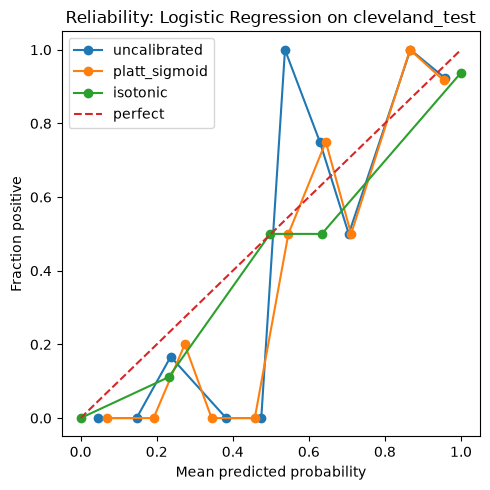

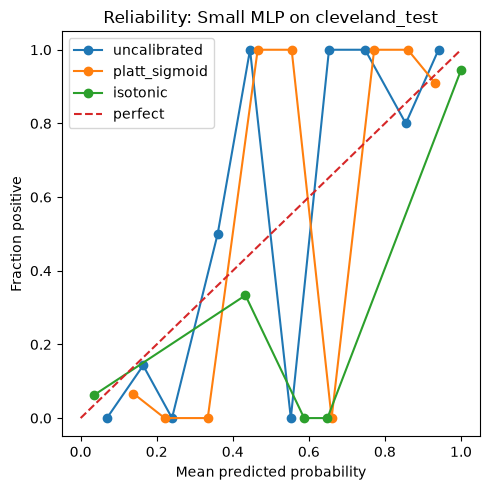

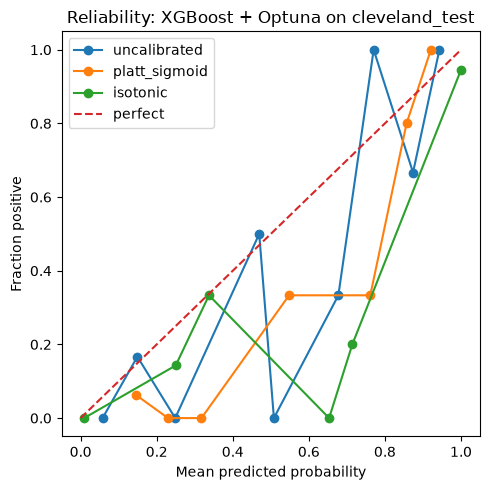

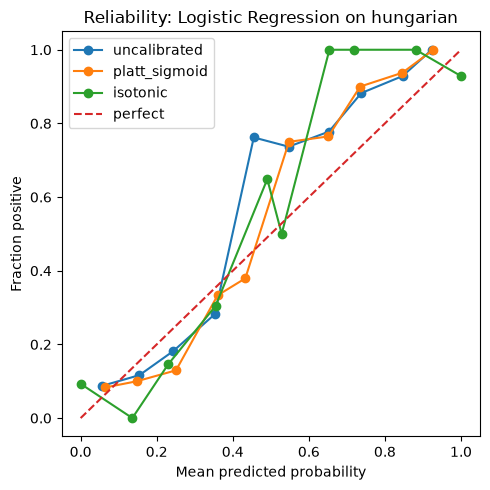

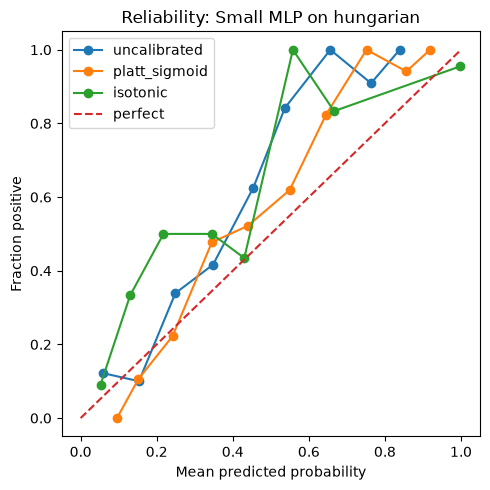

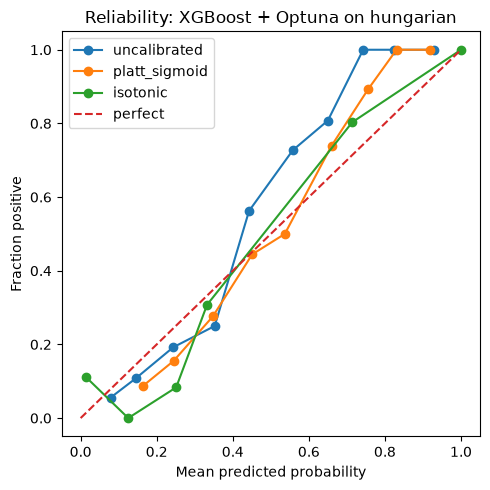

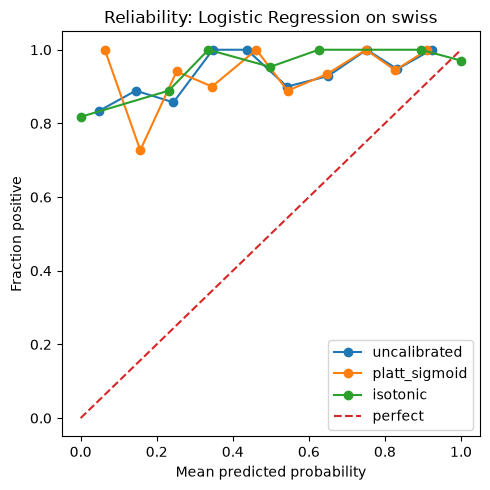

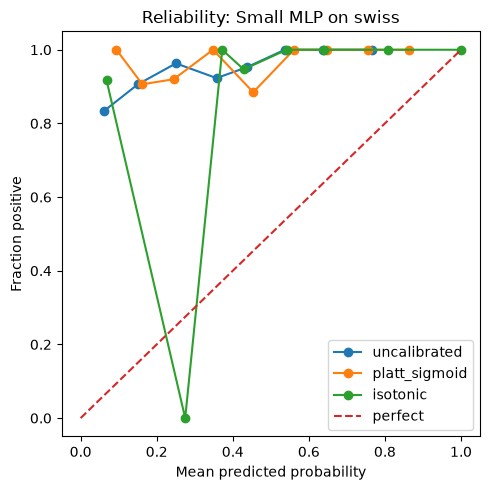

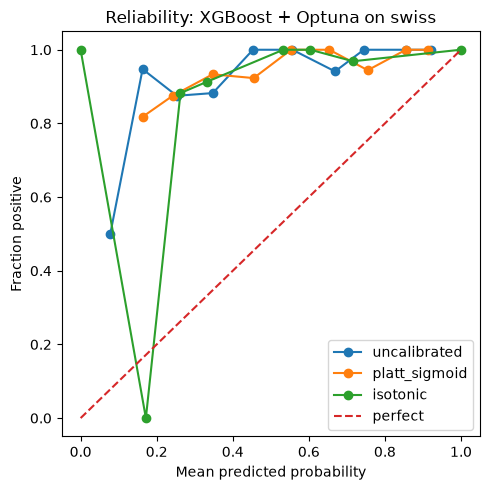

In [8]:
for split_name, df in eval_splits.items():
    X_eval, y_eval = get_xy(df)

    for model_name in sorted({key[0] for key in calibrated_models.keys()}):
        fig, ax = plt.subplots(figsize=(5, 5))

        for calibration in ["uncalibrated", "platt_sigmoid", "isotonic"]:
            model = calibrated_models[(model_name, calibration)]
            prob = model.predict_proba(X_eval)[:, 1]
            frac_pos, mean_pred = calibration_curve(y_eval, prob, n_bins=10, strategy="uniform")
            ax.plot(mean_pred, frac_pos, marker="o", label=calibration)

        ax.plot([0, 1], [0, 1], linestyle="--", label="perfect")
        ax.set_title(f"Reliability: {model_name} on {split_name}")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Fraction positive")
        ax.legend()
        plt.tight_layout()
        plt.show()

## Domain adaptation ablation: CORAL

This ablation compares each model with and without CORAL alignment. CORAL is fitted using unlabeled target-domain features only.

In [9]:
coral_rows = []
X_source, _ = get_xy(train_validation_df)

for split_name, df in eval_splits.items():
    X_target, y_target = get_xy(df)

    for model_name, pipe in models.items():
        pre = pipe.named_steps["preprocess"]
        clf = pipe.named_steps["model"]

        X_source_processed = pre.transform(X_source)
        X_target_processed = pre.transform(X_target)

        coral = phase3.CORALAdapter()
        coral.fit(X_source_processed, X_target_processed)

        X_target_coral = coral.transform_target_to_source(X_target_processed)

        prob_no_adapt = pipe.predict_proba(X_target)[:, 1]
        prob_coral = clf.predict_proba(X_target_coral)[:, 1]

        no_adapt = evaluate_predictions(y_target, prob_no_adapt)
        adapted = evaluate_predictions(y_target, prob_coral)

        for metric in ["roc_auc", "average_precision", "f1", "sensitivity", "specificity"]:
            coral_rows.append({
                "split": split_name,
                "model": model_name,
                "metric": metric,
                "without_coral": no_adapt[metric],
                "with_coral": adapted[metric],
                "delta": adapted[metric] - no_adapt[metric],
            })

coral_df = pd.DataFrame(coral_rows)
coral_df

,split,model,metric,without_coral,with_coral,delta
0,cleveland_test,Logistic Regression,roc_auc,0.948571,0.942857,-0.005714
1,cleveland_test,Logistic Regression,average_precision,0.925530,0.919029,-0.006501
2,cleveland_test,Logistic Regression,f1,0.863636,0.857143,-0.006494
3,cleveland_test,Logistic Regression,sensitivity,0.904762,0.857143,-0.047619
4,cleveland_test,Logistic Regression,specificity,0.840000,0.880000,0.040000
5,cleveland_test,XGBoost + Optuna,roc_auc,0.935238,0.895238,-0.040000
6,cleveland_test,XGBoost + Optuna,average_precision,0.914883,0.842457,-0.072427
7,cleveland_test,XGBoost + Optuna,f1,0.837209,0.842105,0.004896
8,cleveland_test,XGBoost + Optuna,sensitivity,0.857143,0.761905,-0.095238
9,cleveland_test,XGBoost + Optuna,specificity,0.840000,0.960000,0.120000


## SHAP explainability for XGBoost

SHAP TreeExplainer is applied to the XGBoost model because it is tree-based.  
This satisfies the professor's explainability requirement while keeping the method appropriate to the model.

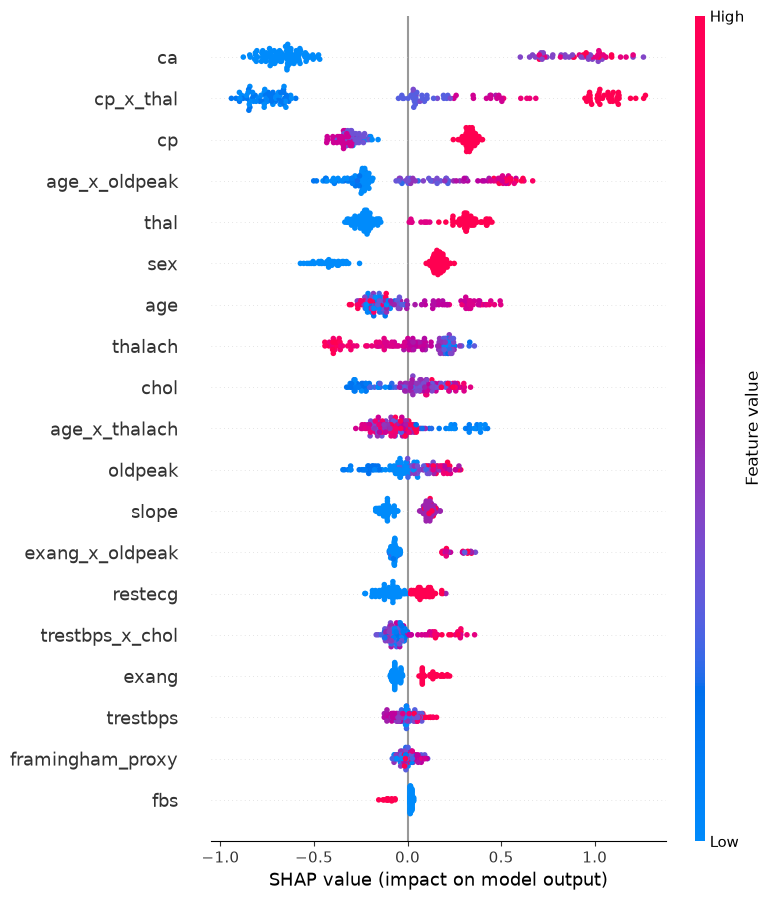

,feature,mean_abs_shap
11,ca,0.750344
16,cp_x_thal,0.666504
2,cp,0.319875
14,age_x_oldpeak,0.293223
12,thal,0.261911
1,sex,0.240588
0,age,0.197862
7,thalach,0.194741
4,chol,0.156389
13,age_x_thalach,0.131333


In [10]:
try:
    import shap

    xgb_pipe = models["XGBoost + Optuna"]
    pre = xgb_pipe.named_steps["preprocess"]
    xgb_model = xgb_pipe.named_steps["model"]

    X_train_val, _ = get_xy(train_validation_df)

    if len(X_train_val) > 150:
        X_sample = X_train_val.sample(150, random_state=RANDOM_STATE)
    else:
        X_sample = X_train_val.copy()

    X_processed = pre.transform(X_sample)
    feature_names = list(pre.named_steps["features"].get_feature_names_out())

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_processed)

    shap.summary_plot(
        shap_values,
        X_processed,
        feature_names=feature_names,
        show=False,
    )
    plt.tight_layout()
    plt.show()

    shap_importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)

    display(shap_importance)

except ImportError:
    print("SHAP is not installed. Install with: pip install shap")
except Exception as exc:
    print(f"SHAP failed: {exc}")